<a href="https://colab.research.google.com/github/nehakumarisah142/ml_classification_projectttt/blob/main/MLHW1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# To import the file from downloads

In [ ]:
from google.colab import files

uploaded = files.upload()
for fn in uploaded.keys():
  print('User uploaded file "{name}" with length {length} bytes'.format(
      name=fn, length=len(uploaded[fn])))

Saving behavioral_indicators_internal_marks (2).csv to behavioral_indicators_internal_marks (2) (2).csv
User uploaded file "behavioral_indicators_internal_marks (2) (2).csv" with length 5463 bytes


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [ ]:
data = pd.read_csv('behavioral_indicators_internal_marks (2).csv')
data.head()

,CRN,Theory_Attendance_Pct,Assignment_Unit_I,Assignment_Unit_II,Assignment_Unit_III,Assignment_PU_6_Set,Lab_Attendance_Pct,Lab_Report_1a,Lab_Report_1b,ML_on_Git,Viva_Marks,Final_Theory_Marks_30,Final_Practical_Marks_20,Total_Internal_Marks_50
0,023-301,38.888889,1.0,0.0,0.0,4,40.0,0.0,0.5,0,1.0,15.760,5.5,21.260
1,023-302,50.000000,1.0,1.0,1.0,4,80.0,1.0,0.5,4,1.5,19.508,19.0,38.508
2,023-303,77.777778,1.0,0.0,0.0,4,100.0,0.0,0.0,4,1.0,16.108,17.0,33.108
3,023-304,55.555556,1.0,1.0,0.5,4,100.0,0.0,1.0,4,1.0,19.632,17.0,36.632
4,023-305,50.000000,1.0,0.0,0.0,4,80.0,1.0,1.0,4,1.0,13.556,18.0,31.556


In [ ]:
data.tail()

,CRN,Theory_Attendance_Pct,Assignment_Unit_I,Assignment_Unit_II,Assignment_Unit_III,Assignment_PU_6_Set,Lab_Attendance_Pct,Lab_Report_1a,Lab_Report_1b,ML_on_Git,Viva_Marks,Final_Theory_Marks_30,Final_Practical_Marks_20,Total_Internal_Marks_50
91,023-392,100.0,0.5,0.0,0.0,4,100.000000,1.0,1.0,4,0.5,14.132,17.5,31.632
92,023-393,62.5,1.0,1.0,0.5,4,71.428571,1.0,1.0,0,0.5,14.412,12.0,26.412
93,023-394,100.0,1.0,1.0,1.0,4,92.857143,1.0,1.0,4,1.0,20.840,13.0,33.840
94,023-395,0.0,0.0,0.0,0.0,0,0.000000,0.0,0.0,0,0.0,0.000,0.0,0.000
95,023-396,0.0,0.0,0.0,0.0,0,0.000000,0.0,0.0,0,0.0,0.000,0.0,0.000


In [ ]:
data.columns

Index(['CRN', 'Theory_Attendance_Pct', 'Assignment_Unit_I',
       'Assignment_Unit_II', 'Assignment_Unit_III', 'Assignment_PU_6_Set',
       'Lab_Attendance_Pct', 'Lab_Report_1a', 'Lab_Report_1b', 'ML_on_Git',
       'Viva_Marks', 'Final_Theory_Marks_30', 'Final_Practical_Marks_20',
       'Total_Internal_Marks_50'],
      dtype='object')

# STEP 2: Drop unwanted columns

In [ ]:
data.drop(columns=['CRN', 'Final_Theory_Marks_30', 'Final_Practical_Marks_20'], inplace=True)

In [ ]:
#data.iloc[24:30].info()
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Theory_Attendance_Pct    96 non-null     float64
 1   Assignment_Unit_I        96 non-null     float64
 2   Assignment_Unit_II       96 non-null     float64
 3   Assignment_Unit_III      96 non-null     float64
 4   Assignment_PU_6_Set      96 non-null     int64  
 5   Lab_Attendance_Pct       96 non-null     float64
 6   Lab_Report_1a            96 non-null     float64
 7   Lab_Report_1b            96 non-null     float64
 8   ML_on_Git                96 non-null     int64  
 9   Viva_Marks               96 non-null     float64
 10  Total_Internal_Marks_50  96 non-null     float64
dtypes: float64(9), int64(2)
memory usage: 8.4 KB


<Axes: >

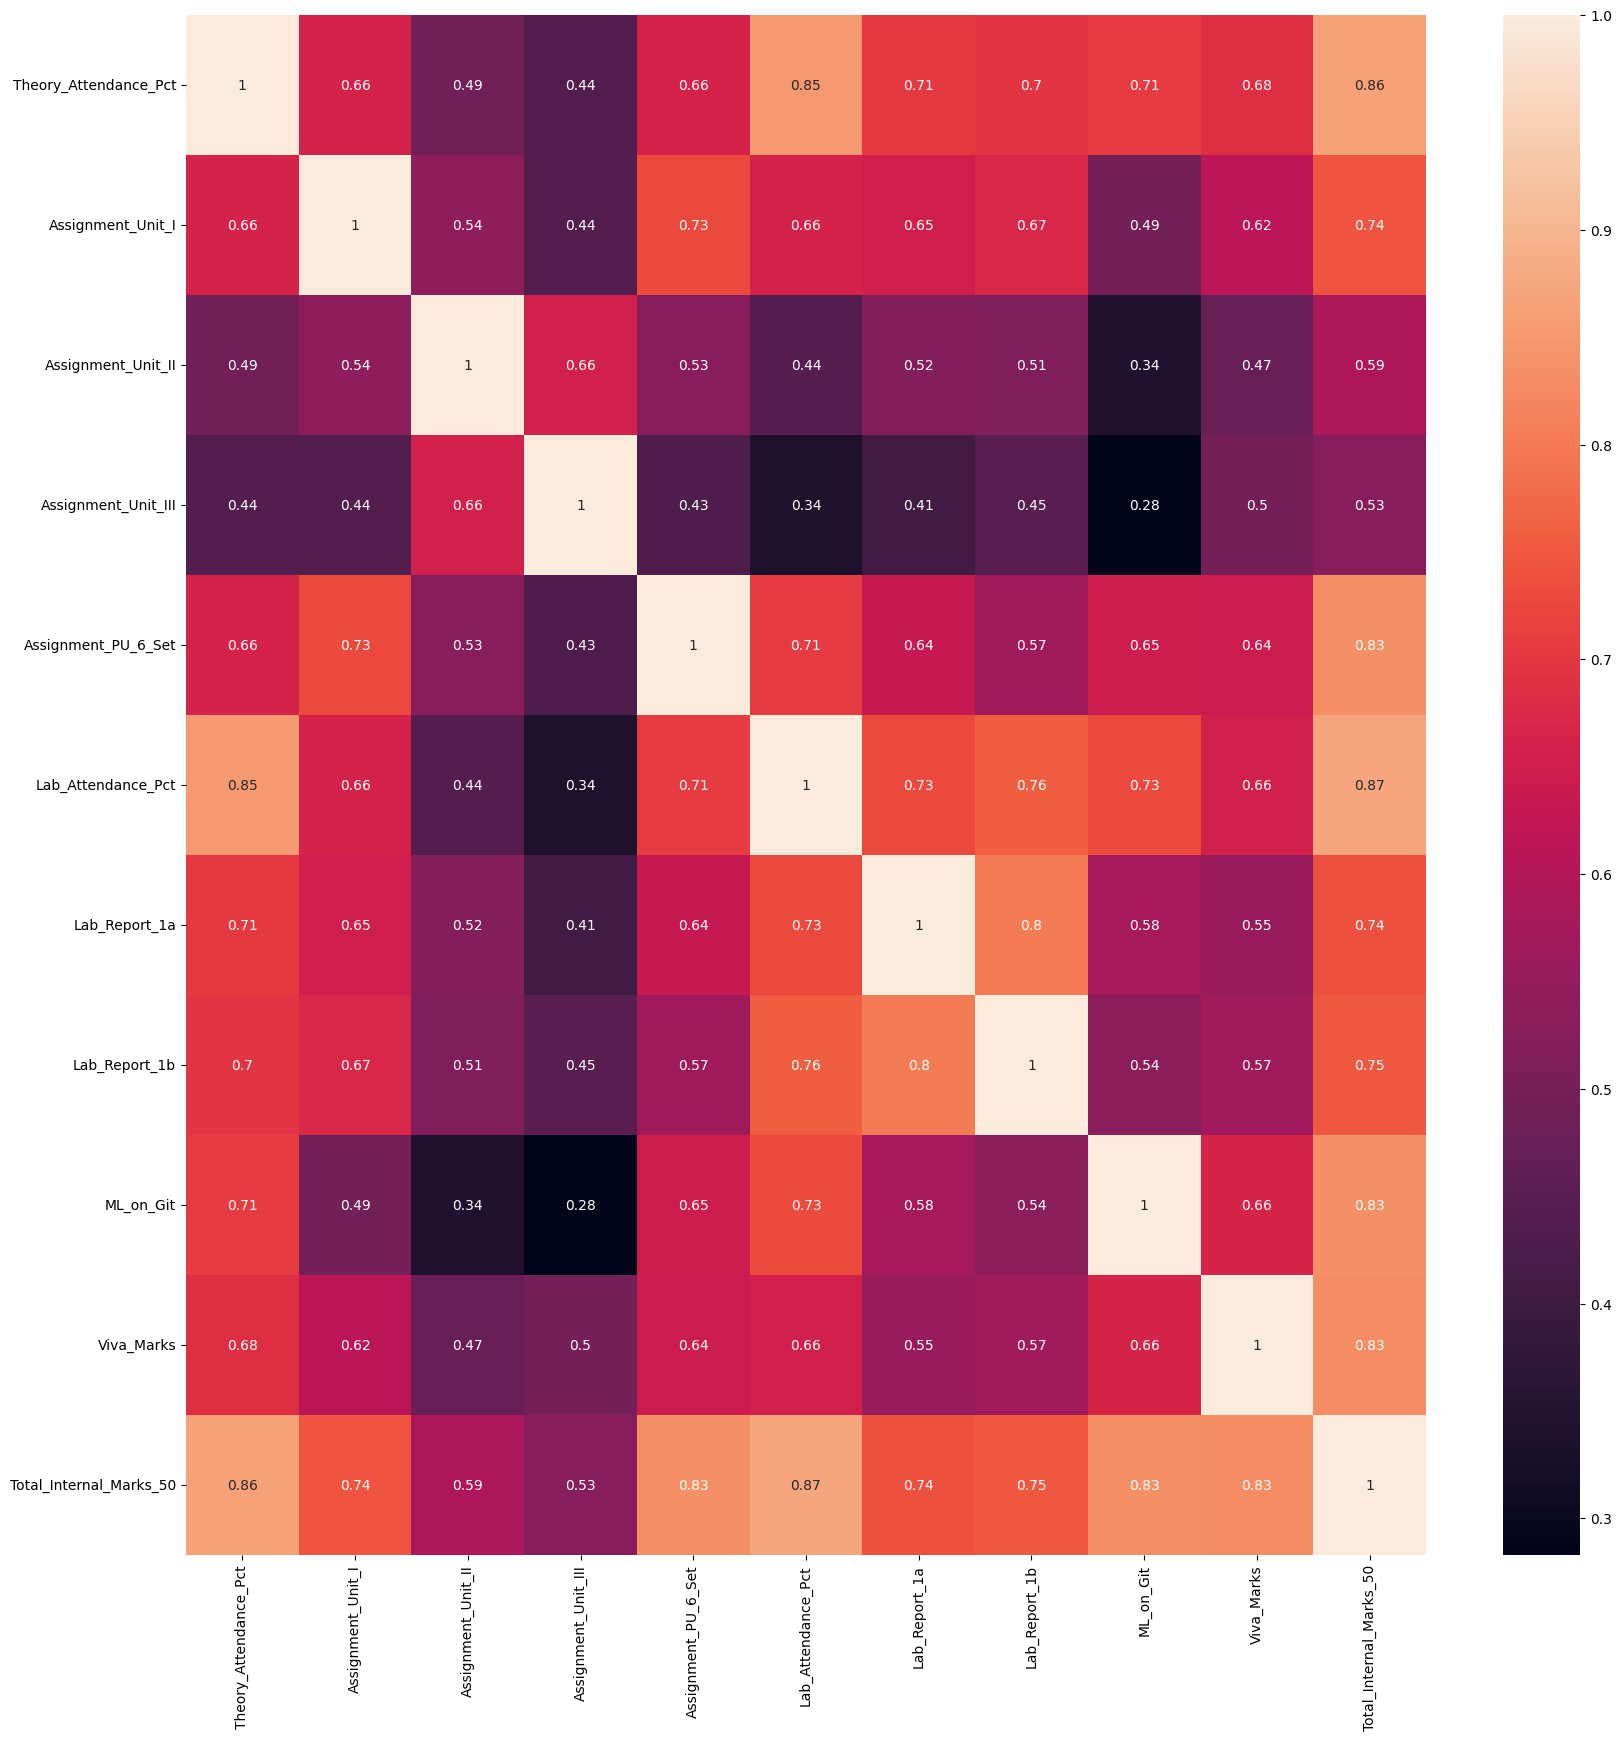

In [ ]:
selected_data=data.select_dtypes(include="number").corr()
plt.figure(figsize=(20,20))
sns.heatmap(selected_data, annot=True)

In [ ]:
data.columns

Index(['Theory_Attendance_Pct', 'Assignment_Unit_I', 'Assignment_Unit_II',
       'Assignment_Unit_III', 'Assignment_PU_6_Set', 'Lab_Attendance_Pct',
       'Lab_Report_1a', 'Lab_Report_1b', 'ML_on_Git', 'Viva_Marks',
       'Total_Internal_Marks_50'],
      dtype='object')

In [ ]:
data.info()
#print(data.iloc[24:30])

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 96 entries, 0 to 95
Data columns (total 11 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Theory_Attendance_Pct    96 non-null     float64
 1   Assignment_Unit_I        96 non-null     float64
 2   Assignment_Unit_II       96 non-null     float64
 3   Assignment_Unit_III      96 non-null     float64
 4   Assignment_PU_6_Set      96 non-null     int64  
 5   Lab_Attendance_Pct       96 non-null     float64
 6   Lab_Report_1a            96 non-null     float64
 7   Lab_Report_1b            96 non-null     float64
 8   ML_on_Git                96 non-null     int64  
 9   Viva_Marks               96 non-null     float64
 10  Total_Internal_Marks_50  96 non-null     float64
dtypes: float64(9), int64(2)
memory usage: 8.4 KB


# Data Preprocessing, handling missing values

In [ ]:
data.isnull().sum()

,0
Theory_Attendance_Pct,0
Assignment_Unit_I,0
Assignment_Unit_II,0
Assignment_Unit_III,0
Assignment_PU_6_Set,0
Lab_Attendance_Pct,0
Lab_Report_1a,0
Lab_Report_1b,0
ML_on_Git,0
Viva_Marks,0


No missing values at all so no need to handle missing values

#Dividing data into training and testing sets

In [ ]:
X=data.drop(columns=["Total_Internal_Marks_50"])#drops the column named total internal marks 50
y=data["Total_Internal_Marks_50"]
print(X)
print(y)
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test=train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=2
)
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

    Theory_Attendance_Pct  Assignment_Unit_I  Assignment_Unit_II  \
0               38.888889                1.0                 0.0   
1               50.000000                1.0                 1.0   
2               77.777778                1.0                 0.0   
3               55.555556                1.0                 1.0   
4               50.000000                1.0                 0.0   
..                    ...                ...                 ...   
91             100.000000                0.5                 0.0   
92              62.500000                1.0                 1.0   
93             100.000000                1.0                 1.0   
94               0.000000                0.0                 0.0   
95               0.000000                0.0                 0.0   

    Assignment_Unit_III  Assignment_PU_6_Set  Lab_Attendance_Pct  \
0                   0.0                    4           40.000000   
1                   1.0                    4   

# Apply Linear Regression

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)
# Extract the weights from the trained model
coefficients = model.coef_
b0=model.intercept_

print(f"Intercept (b0): {b0:.4f}")
for col, coef in zip(X_train.columns, coefficients):
    print(f"Coefficient for {col}: {coef:.4f}")

Intercept (b0): -0.3327
Coefficient for Theory_Attendance_Pct: 0.0574
Coefficient for Assignment_Unit_I: 0.7623
Coefficient for Assignment_Unit_II: 0.8187
Coefficient for Assignment_Unit_III: 2.4105
Coefficient for Assignment_PU_6_Set: 1.7718
Coefficient for Lab_Attendance_Pct: 0.0714
Coefficient for Lab_Report_1a: -0.7469
Coefficient for Lab_Report_1b: 2.8591
Coefficient for ML_on_Git: 2.0045
Coefficient for Viva_Marks: 5.4289


 Y = β₀ + β₁x₁ + β₂x₂ + ... + βₖxₖ

In [ ]:

# Wrap the values in double square brackets [[ ... ]] to make it 2D
single_student_data = [[100, 1, 1, 1, 4, 100, 1, 1, 4, 2]]
predicted_mark = model.predict(single_student_data)
print(f"Predicted Internal Marks: {predicted_mark[0]:.2f} out of 50")

Predicted Internal Marks: 44.61 out of 50


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [ ]:
y_pred = model.predict(X_test)

In [ ]:
import pandas as pd
import numpy as np

def calculate_mae(y_actual, y_predicted):
    return np.mean(np.abs(y_actual - y_predicted))
b0 = model.intercept_
w = model.coef_  # This is an array of weights (b1, b2, b3...)
Yp = np.dot(X_test, w) + b0

results = pd.DataFrame({
    "Actual_Y": y_test.values,
    "Predicted_Y": Yp
})

results["Error"] = results["Actual_Y"] - results["Predicted_Y"]

print("--- Prediction Comparison Table ---")
print(results.head())
print("\n")

# Calculate MAE
mae_value = calculate_mae(results["Actual_Y"], results["Predicted_Y"])
print(f"Mean Absolute Error (MAE): {mae_value:.4f}")

--- Prediction Comparison Table ---
   Actual_Y  Predicted_Y     Error
0    36.040    36.454051 -0.414051
1    27.312    26.105037  1.206963
2    30.520    33.149978 -2.629978
3    32.640    34.207145 -1.567145
4     0.000    -0.332737  0.332737


Mean Absolute Error (MAE): 2.0002


In [ ]:
import numpy as np
import pandas as pd

def MSE(y_actual, y_predicted):
    return np.mean((y_actual - y_predicted) ** 2)

b0 = model.intercept_
w = model.coef_
Yp = np.dot(X_test, w) + b0

# Creates comparison table
results = pd.DataFrame({
    "Actual_Y": y_test.values,
    "Predicted_Y": Yp
})

# Calculate MSE
mse_value = MSE(results["Actual_Y"], results["Predicted_Y"])

print("--- Custom Evaluation ---")
print(f"Mean Squared Error (MSE): {mse_value:.4f}")

--- Custom Evaluation ---
Mean Squared Error (MSE): 6.3152


In [ ]:
rmse = np.sqrt(mse_value)

In [ ]:
import numpy as np

def R2_Score(y_actual, y_predicted):
    y_mean = np.mean(y_actual)
    Udiff_err = np.sum((y_actual - y_predicted) ** 2)
    Dvar = np.sum((y_actual - y_mean) ** 2)
    return 1 - (Udiff_err /Dvar)

# Calculate R2 score
r2_value = R2_Score(results["Actual_Y"], results["Predicted_Y"])
print(f"R-squared (R2) Score: {r2_value:.4f}")

R-squared (R2) Score: 0.9316


In [ ]:
print(f"Mean Absolute Error (MAE): {mae_value:.4f}")
print(f"Mean Squared Error (MSE): {mse_value:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared (R2): {r2_value:.4f}")

Mean Absolute Error (MAE): 2.0002
Mean Squared Error (MSE): 6.3152
Root Mean Squared Error (RMSE): 2.5130
R-squared (R2): 0.9316


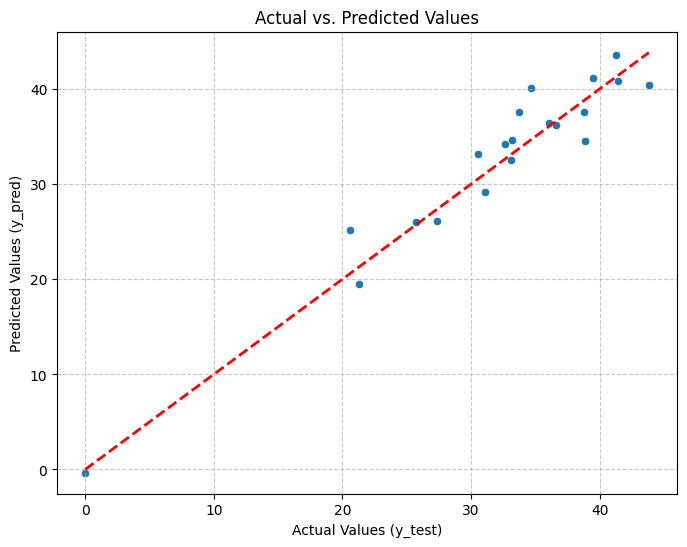

In [ ]:
plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Values (y_test)")
plt.ylabel("Predicted Values (y_pred)")
plt.title("Actual vs. Predicted Values")
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()